notebook to figure out what is happening with the closed-form autocorrleation function, also to check why the variance ratio is not working as expected

In [2]:
from methane_noise_forcing import closed_form
import numpy as np
import matplotlib.pyplot as plt

In [46]:
tau_methane = 10
tau_forcing = 1
dt_large = 1
dt_small = 0.1
n_lag_years = 80
lags_large = np.arange(0, n_lag_years / dt_large, 1)
lags_small = np.arange(0, (n_lag_years) / dt_small, 1)

Text(0, 0.5, 'autocorrelation')

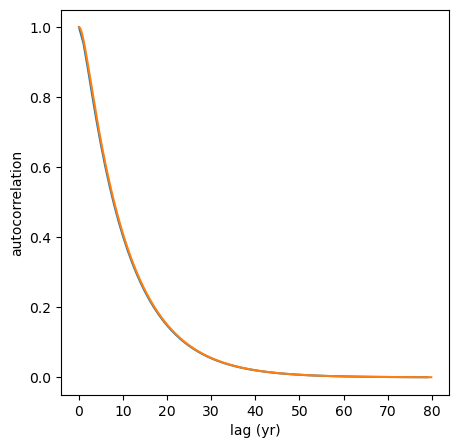

In [47]:
## calculate and plot autocorrelations
autocorr_large = closed_form.calculate_two_timescale_autocorrelation(
    phi_0=np.exp(-dt_large / tau_methane),
    phi_1=np.exp(-dt_large / tau_forcing),
    lags=lags_large,
)
autocorr_small = closed_form.calculate_two_timescale_autocorrelation(
    phi_0=np.exp(-dt_small / tau_methane),
    phi_1=np.exp(-dt_small / tau_forcing),
    lags=lags_small,
)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(lags_large * dt_large, autocorr_large, label="large dt")
ax.plot(lags_small * dt_small, autocorr_small, label="small dt")
ax.set_xlabel("lag (yr)")
ax.set_ylabel("autocorrelation")

In [48]:
np.sum(autocorr_large)

np.float64(11.33619493593887)

In [49]:
np.sum(autocorr_small)

np.float64(110.4442395268102)

In [50]:
lags_large.shape

(80,)

In [51]:
lags_small.shape

(800,)

There is a bit of a strange discrepancy between the autocorrelations, but that's within error. The sum of the autocorrelations is behaving as expected, where the sum over the same number of years is scaling by the number of samples for the autocorrelation.

Below, I test for if the c_tau behaves as expected

In [ ]:
from methane_noise_forcing.core import FirnFilter

mode = 40  # years
fwhm = 26  # years
skew = 0.65
t_max = 200
firn_filter_large = FirnFilter.fit_log_logistic(
    mode=mode, fwhm=fwhm, skew=skew, t_max=t_max, dt=dt_large
)
firn_filter_small = FirnFilter.fit_log_logistic(
    mode=mode, fwhm=fwhm, skew=skew, t_max=t_max, dt=dt_small
)
# normalize kernels by sum
firn_filter_large.kernel /= np.sum(firn_filter_large.kernel)
firn_filter_small.kernel /= np.sum(firn_filter_small.kernel)

# calculate self_overlaps
c_taus_large = closed_form.calculate_kernel_self_lag(
    firn_filter_large.kernel, lags=lags_large, dt=dt_large
)
c_taus_small = closed_form.calculate_kernel_self_lag(
    firn_filter_small.kernel, lags=lags_small, dt=dt_small
)